In [57]:
import os
import glob
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask as rio_mask
from rasterio.features import geometry_mask
from shapely.geometry import box
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm

In [58]:
# ================== Land Cover Zonal Stats Settings ==================
LANDCOVER_RASTER = r"/Users/ks/Desktop/Wu/Land_Cover25/Land_Cover25.tif"     # NLCD-style land cover raster
GRID_SHAPEFILE = r"../02_Manage_Ecostress_Data/Grids/Sacramento/Sac_grid.shp"  # same grid used for ECOSTRESS/variable stats
GRID_ID_FIELD = "GRID_ID"

OUTPUT_DIR = r"01_LandCover_Zonal_Stats"
os.makedirs(OUTPUT_DIR, exist_ok=True)
LANDCOVER_GPKG = os.path.join(OUTPUT_DIR, "LandCover_Majority.gpkg")
LANDCOVER_PNG = os.path.join(OUTPUT_DIR, "LandCover_Majority.png")

grid_gdf = gpd.read_file(GRID_SHAPEFILE)
print(f"Loaded {len(grid_gdf)} grid cells from {GRID_SHAPEFILE}")

Loaded 4255 grid cells from ../02_Manage_Ecostress_Data/Grids/Sacramento/Sac_grid.shp


In [59]:
def compute_majority_landcover(grid_orig, raster_path, grid_id_field=GRID_ID_FIELD):
    """
    For each grid cell, finds the majority (most frequent) land cover class
    from the raster pixels that fall inside the cell.

    Returns a GeoDataFrame copy of grid_orig with added columns:
      - LC_Majority : the most common land cover class code in the cell
      - n_valid_px  : number of valid (non-nodata) pixels used
    """
    grid = grid_orig.reset_index(drop=True).copy()

    with rasterio.open(raster_path) as src:
        grid_work = grid.to_crs(src.crs)
        raster_extent = box(*src.bounds)
        nodata = src.nodata

        n_cells = len(grid_work)
        majority_arr = np.full(n_cells, np.nan, dtype="float32")
        n_valid_arr = np.zeros(n_cells, dtype="int32")

        for i, row in grid_work.iterrows():
            geom = row.geometry
            if not geom.intersects(raster_extent):
                continue

            geom_clip = geom.intersection(raster_extent)
            if geom_clip.is_empty:
                continue

            try:
                out_img, out_transform = rio_mask(
                    src, [geom_clip], crop=True, filled=True,
                    nodata=nodata if nodata is not None else 0
                )
            except ValueError:
                continue

            data = out_img[0]
            inside_mask = geometry_mask(
                [geom_clip],
                out_shape=data.shape,
                transform=out_transform,
                all_touched=False,
                invert=True,
            )

            data_inside = data[inside_mask]

            if nodata is not None:
                data_inside = data_inside[data_inside != nodata]

            if data_inside.size == 0:
                continue

            values, counts = np.unique(data_inside, return_counts=True)
            majority_arr[i] = values[np.argmax(counts)]
            n_valid_arr[i] = data_inside.size

    grid["LC_Majority"] = majority_arr
    grid["n_valid_px"] = n_valid_arr
    return grid

In [60]:
landcover_gdf = compute_majority_landcover(grid_gdf, LANDCOVER_RASTER, grid_id_field=GRID_ID_FIELD)

n_with_data = landcover_gdf["LC_Majority"].notna().sum()
print(f"Computed majority land cover for {n_with_data} / {len(landcover_gdf)} grid cells")

landcover_gdf.to_file(LANDCOVER_GPKG, driver="GPKG")
print(f"Saved -> {LANDCOVER_GPKG}")

landcover_gdf["LC_Majority"].value_counts(dropna=False).sort_index()

Computed majority land cover for 4255 / 4255 grid cells
Saved -> 01_LandCover_Zonal_Stats/LandCover_Majority.gpkg


LC_Majority
11.0     156
21.0      75
22.0     273
23.0     663
24.0      40
31.0      11
41.0      16
42.0       6
52.0      44
71.0    1198
81.0      14
82.0    1683
90.0       9
95.0      67
Name: count, dtype: int64

/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_27266/2498824306.py:42: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  landcover_gdf[~has_data].plot(ax=ax, color="white", edgecolor="black", linewidth=0.2)


Saved -> 01_LandCover_Zonal_Stats/LandCover_Majority.png


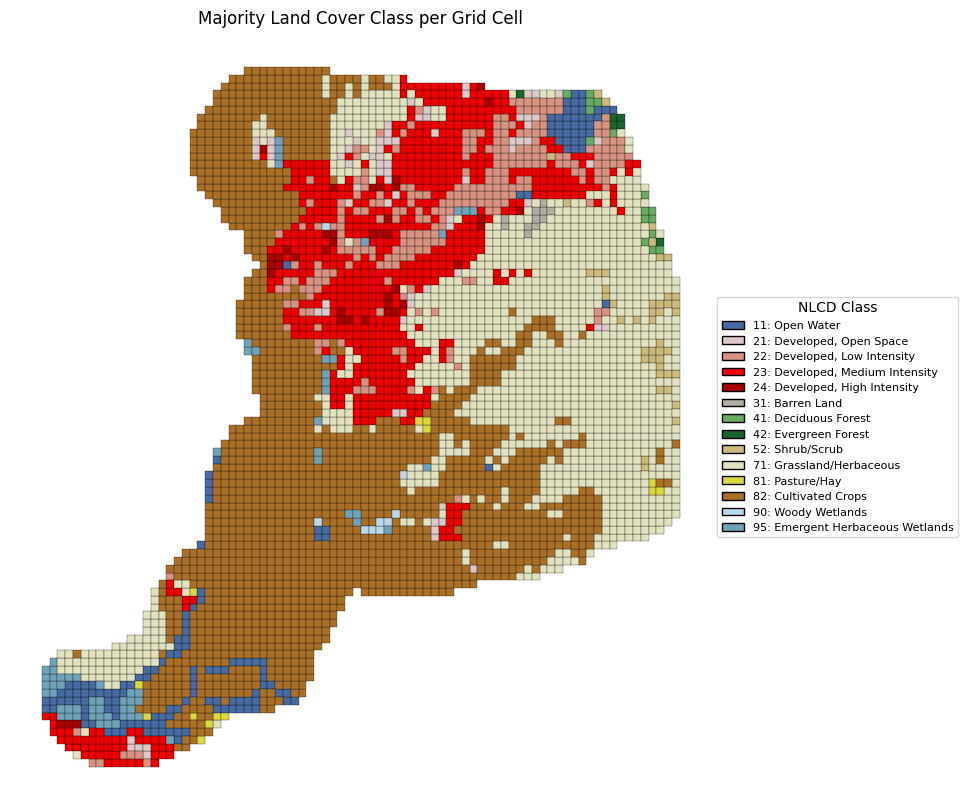

In [61]:
# Standard NLCD 2019/2021 class colors
NLCD_COLORS = {
    11: "#476BA0",  # Open Water
    12: "#D1DDF9",  # Perennial Ice/Snow
    21: "#DDC9C9",  # Developed, Open Space
    22: "#D89382",  # Developed, Low Intensity
    23: "#ED0000",  # Developed, Medium Intensity
    24: "#AA0000",  # Developed, High Intensity
    31: "#B2ADA3",  # Barren Land
    41: "#68AA63",  # Deciduous Forest
    42: "#1C6330",  # Evergreen Forest
    43: "#B5C98E",  # Mixed Forest
    51: "#A58C30",  # Dwarf Scrub
    52: "#CCBA7C",  # Shrub/Scrub
    71: "#E2E2C1",  # Grassland/Herbaceous
    72: "#C9C977",  # Sedge/Herbaceous
    73: "#99C147",  # Lichens
    74: "#77AD93",  # Moss
    81: "#DBD83D",  # Pasture/Hay
    82: "#AA7028",  # Cultivated Crops
    90: "#BAD8EA",  # Woody Wetlands
    95: "#70A3BA",  # Emergent Herbaceous Wetlands
}

NLCD_LABELS = {
    11: "Open Water", 12: "Perennial Ice/Snow", 21: "Developed, Open Space",
    22: "Developed, Low Intensity", 23: "Developed, Medium Intensity",
    24: "Developed, High Intensity", 31: "Barren Land", 41: "Deciduous Forest",
    42: "Evergreen Forest", 43: "Mixed Forest", 51: "Dwarf Scrub",
    52: "Shrub/Scrub", 71: "Grassland/Herbaceous", 72: "Sedge/Herbaceous",
    73: "Lichens", 74: "Moss", 81: "Pasture/Hay", 82: "Cultivated Crops",
    90: "Woody Wetlands", 95: "Emergent Herbaceous Wetlands",
}


def plot_majority_landcover(landcover_gdf, out_path):
    """Plots the majority land cover class per grid cell using NLCD colors."""
    fig, ax = plt.subplots(figsize=(10, 10))

    has_data = landcover_gdf["LC_Majority"].notna()

    landcover_gdf[~has_data].plot(ax=ax, color="white", edgecolor="black", linewidth=0.2)

    present_classes = sorted(landcover_gdf.loc[has_data, "LC_Majority"].unique())

    for lc_class in present_classes:
        subset = landcover_gdf[landcover_gdf["LC_Majority"] == lc_class]
        color = NLCD_COLORS.get(int(lc_class), "#FFFFFF")
        subset.plot(ax=ax, color=color, edgecolor="black", linewidth=0.2)

    legend_elements = [
        Patch(facecolor=NLCD_COLORS.get(int(lc), "#FFFFFF"), edgecolor="black",
              label=f"{int(lc)}: {NLCD_LABELS.get(int(lc), 'Unknown')}")
        for lc in present_classes
    ]
    ax.legend(handles=legend_elements, loc="center left", bbox_to_anchor=(1.0, 0.5),
               fontsize=8, title="NLCD Class")

    ax.set_title("Majority Land Cover Class per Grid Cell")
    ax.axis("off")

    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    return out_path


png_path = plot_majority_landcover(landcover_gdf, LANDCOVER_PNG)
print(f"Saved -> {png_path}")
plt.show()

Merge land cover into the combined variable stats table

In [62]:
# Load the existing merged variable statistics (BuildingFootprint, ImperviousSurface, TreeCanopy)
VARIABLE_STATS_GPKG = r"../03_Variable_Zonal_Stats/Grid_Zonal_Stats/Grid_Zonal_Stats/01_Variable_Statistics.gpkg"
COMBINED_WITH_LC_GPKG = os.path.join(OUTPUT_DIR, "02_Variable_Statistics_with_LandCover.gpkg")

variable_gdf = gpd.read_file(VARIABLE_STATS_GPKG)
print(f"Loaded variable stats: {len(variable_gdf)} rows, columns: {list(variable_gdf.columns)}")

# match dtypes on the join key to avoid silent merge failures
variable_gdf["GRID_ID"] = variable_gdf["GRID_ID"].astype(str)
landcover_gdf["GRID_ID"] = landcover_gdf["GRID_ID"].astype(str)

lc_no_geom = landcover_gdf[["GRID_ID", "LC_Majority"]]

combined_gdf = variable_gdf.merge(lc_no_geom, on="GRID_ID", how="left")
combined_gdf = gpd.GeoDataFrame(combined_gdf, geometry="geometry", crs=variable_gdf.crs)

n_missing_lc = combined_gdf["LC_Majority"].isna().sum()
if n_missing_lc > 0:
    print(f"Warning: {n_missing_lc} grid cell(s) have no matching land cover value.")

combined_gdf.to_file(COMBINED_WITH_LC_GPKG, driver="GPKG")
print(f"Saved -> {COMBINED_WITH_LC_GPKG}")

combined_gdf.head()

Loaded variable stats: 39940 rows, columns: ['GRID_ID', 'BuildingFootprint_mean', 'ImperviousSurface_mean', 'TreeCanopy_mean', 'geometry']


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pyogrio/geopandas.py:662: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


Saved -> 01_LandCover_Zonal_Stats/02_Variable_Statistics_with_LandCover.gpkg


,GRID_ID,BuildingFootprint_mean,ImperviousSurface_mean,TreeCanopy_mean,geometry,LC_Majority
0,AAA-1000,0.0,0.145045,3.935135,"POLYGON ((328523.871 -548012.65, 328523.871 -5...",NaN
1,AAA-1001,0.0,0.000000,8.623201,"POLYGON ((328523.871 -549012.65, 328523.871 -5...",NaN
2,AAA-1002,0.0,0.000000,3.965797,"POLYGON ((328523.871 -550012.649, 328523.871 -...",NaN
3,AAA-1003,0.0,0.000000,3.860486,"POLYGON ((328523.871 -551012.65, 328523.871 -5...",NaN
4,AAA-1004,0.0,0.000000,8.619262,"POLYGON ((328523.871 -552012.649, 328523.871 -...",NaN


In [63]:
# ================== Bring in LST phase data and filter to grids with LST ==================
PHASE_STATS_GPKG = r"../03_Variable_Zonal_Stats/Grid_Zonal_Stats/Grid_Zonal_Stats/02_Variable_and_Phase_Statistics.gpkg"
PHASE_CATEGORIES = ["Night", "Morning", "Afternoon", "Evening"]

phase_gdf = gpd.read_file(PHASE_STATS_GPKG)
print(f"Loaded phase stats: {len(phase_gdf)} rows, columns: {list(phase_gdf.columns)}")

existing_phase_cols = [c for c in PHASE_CATEGORIES if c in phase_gdf.columns]
if not existing_phase_cols:
    raise KeyError(f"None of {PHASE_CATEGORIES} found in {PHASE_STATS_GPKG}. "
                    f"Columns: {list(phase_gdf.columns)}")

phase_gdf["GRID_ID"] = phase_gdf["GRID_ID"].astype(str)
combined_gdf["GRID_ID"] = combined_gdf["GRID_ID"].astype(str)

# pull just the join key + phase columns (no geometry, to avoid duplicate geometry columns)
phase_cols_only = phase_gdf[["GRID_ID"] + existing_phase_cols]

combined_gdf = combined_gdf.merge(phase_cols_only, on="GRID_ID", how="left")

has_lst = combined_gdf[existing_phase_cols].notna().any(axis=1)

n_before = len(combined_gdf)
combined_gdf = combined_gdf[has_lst].reset_index(drop=True)
n_after = len(combined_gdf)

print(f"Removed {n_before - n_after} grid cell(s) with no LST values in any phase "
      f"({existing_phase_cols}).")
print(f"Remaining: {n_after} grid cells")

combined_gdf = gpd.GeoDataFrame(combined_gdf, geometry="geometry", crs=combined_gdf.crs)
combined_gdf.head()

Loaded phase stats: 4255 rows, columns: ['GRID_ID', 'Night', 'Morning', 'Evening', 'BuildingFootprint_mean', 'ImperviousSurface_mean', 'TreeCanopy_mean', 'geometry']
Removed 35685 grid cell(s) with no LST values in any phase (['Night', 'Morning', 'Evening']).
Remaining: 4255 grid cells


,GRID_ID,BuildingFootprint_mean,ImperviousSurface_mean,TreeCanopy_mean,geometry,LC_Majority,Night,Morning,Evening
0,HA-442,0.000000,0.035135,0.000000,"POLYGON ((-165476.129 9987.35, -165476.129 898...",95.0,292.283203,294.358124,298.026855
1,HA-443,0.000000,0.000000,0.000000,"POLYGON ((-165476.129 8987.351, -165476.129 79...",95.0,294.212341,295.723083,297.867950
2,HA-444,0.005405,0.000000,0.000000,"POLYGON ((-165476.129 7987.35, -165476.129 698...",95.0,294.627930,295.863434,298.288757
3,HA-445,0.000000,0.000000,0.282628,"POLYGON ((-165476.129 6987.351, -165476.129 59...",95.0,293.964661,295.675171,298.392059
4,HA-446,0.000000,0.000000,1.377477,"POLYGON ((-165476.129 5987.351, -165476.129 49...",11.0,292.858337,295.048645,297.118988


In [64]:
lcz_colors = {
    'LCZ 1': '#8B0000', 'LCZ 2': '#FF0000', 'LCZ 3': '#FF4500', 'LCZ 4': '#FFA500',
    'LCZ 5': '#FFFF00', 'LCZ 6': '#C0C0C0', 'LCZ 7': '#F5DEB3', 'LCZ 8': '#A0522D',
    'LCZ 9': '#8B4513', 'LCZ 10': '#A9A9A9', 'LCZ A': '#006400', 'LCZ B': '#32CD32',
    'LCZ C': '#9ACD32', 'LCZ D': '#DEB887', 'LCZ E': '#696969', 'LCZ F': '#F5F5DC',
    'LCZ G': '#1E90FF', 'LCZ X': '#FFFFFF'
}

strictness_colors = {1: '#8B0000', 2: '#FF4500', 3: '#FFB6C1', 0: '#FFFFFF'}


def classify_lcz_strict(row):
    imperv = row['ImperviousSurface_mean']
    tree_cover = row['TreeCanopy_mean']
    lc_val = row['LC_Majority']

    if pd.isna(lc_val):
        return 'LCZ X', 0

    if lc_val == 11:
        return 'LCZ G', 1
    elif lc_val == 21:
        if tree_cover > 40:
            return 'LCZ B', 1
        elif imperv > 80:
            return 'LCZ E', 1
        else:
            return 'LCZ 9', 1
    elif lc_val == 22:
        return ('LCZ 6', 1) if imperv > 70 else ('LCZ 9', 1)
    elif lc_val == 23:
        return ('LCZ 5', 1) if imperv > 60 else ('LCZ X', 0)
    elif lc_val == 24:
        return 'LCZ 2', 1
    elif lc_val in [41, 42, 43]:
        if tree_cover > 80:
            return 'LCZ A', 1
        elif tree_cover > 60:
            return 'LCZ B', 1
        else:
            return 'LCZ X', 0
    elif lc_val in [52, 71]:
        return 'LCZ C', 1
    elif lc_val in [81, 82]:
        return 'LCZ D', 1
    elif lc_val == 90:
        return 'LCZ A', 1
    elif lc_val == 95:
        return 'LCZ F', 1

    return 'LCZ X', 0


def classify_lcz_medium(row):
    imperv = row['ImperviousSurface_mean']
    tree_cover = row['TreeCanopy_mean']
    lc_val = row['LC_Majority']

    if pd.isna(lc_val):
        return 'LCZ X', 0

    if lc_val == 11:
        return 'LCZ G', 2
    elif lc_val == 21:
        if tree_cover > 30:
            return 'LCZ B', 2
        elif imperv > 70:
            return 'LCZ E', 2
        else:
            return 'LCZ 9', 2
    elif lc_val == 22:
        return ('LCZ 6', 2) if imperv > 60 else ('LCZ 9', 2)
    elif lc_val == 23:
        return 'LCZ 5', 2
    elif lc_val == 24:
        return 'LCZ 2', 2
    elif lc_val in [41, 42, 43]:
        return ('LCZ A', 2) if tree_cover > 70 else ('LCZ B', 2)
    elif lc_val in [52, 71]:
        return 'LCZ C', 2
    elif lc_val in [81, 82]:
        return 'LCZ D', 2
    elif lc_val == 90:
        return 'LCZ A', 2
    elif lc_val == 95:
        return 'LCZ F', 2

    return 'LCZ X', 0


def classify_lcz_flexible(row):
    imperv = row['ImperviousSurface_mean']
    tree_cover = row['TreeCanopy_mean']
    lc_val = row['LC_Majority']

    if pd.isna(lc_val):
        return 'LCZ X', 3

    if lc_val == 11:
        return 'LCZ G', 3
    elif lc_val == 21:
        if tree_cover > 20:
            return 'LCZ B', 3
        elif imperv > 50:
            return 'LCZ E', 3
        else:
            return 'LCZ 9', 3
    elif lc_val == 22:
        return ('LCZ 6', 3) if imperv > 40 else ('LCZ 9', 3)
    elif lc_val == 23:
        return 'LCZ 5', 3
    elif lc_val == 24:
        return 'LCZ 2', 3
    elif lc_val in [41, 42, 43]:
        return ('LCZ A', 3) if tree_cover > 50 else ('LCZ B', 3)
    elif lc_val in [52, 71]:
        return 'LCZ C', 3
    elif lc_val in [81, 82]:
        return 'LCZ D', 3
    elif lc_val == 90:
        return 'LCZ A', 3
    elif lc_val == 95:
        return 'LCZ F', 3

    return 'LCZ X', 3


def classify_lcz_waterfall(row):
    lcz_strict, level_strict = classify_lcz_strict(row)
    if lcz_strict != 'LCZ X':
        return lcz_strict, level_strict

    lcz_medium, level_medium = classify_lcz_medium(row)
    if lcz_medium != 'LCZ X':
        return lcz_medium, level_medium

    return classify_lcz_flexible(row)

LCZ distribution:
LCZ_final
LCZ D    1697
LCZ C    1242
LCZ 5     663
LCZ 9     348
LCZ G     156
LCZ F      67
LCZ 2      40
LCZ B      22
LCZ X      11
LCZ A       9
Name: count, dtype: int64

Strictness level distribution:
Strictness_Level
1    3664
2     580
3      11
Name: count, dtype: int64

Loaded base gpkg: 4255 rows, columns: ['GRID_ID', 'Night', 'Morning', 'Evening', 'BuildingFootprint_mean', 'ImperviousSurface_mean', 'TreeCanopy_mean', 'geometry']

Saved -> 02_LCZ_Classification/LCZ_Classification.gpkg
Index(['GRID_ID', 'Night', 'Morning', 'Evening', 'BuildingFootprint_mean',
       'ImperviousSurface_mean', 'TreeCanopy_mean', 'geometry', 'LC_Majority',
       'LCZ_final', 'Strictness_Level'],
      dtype='object')


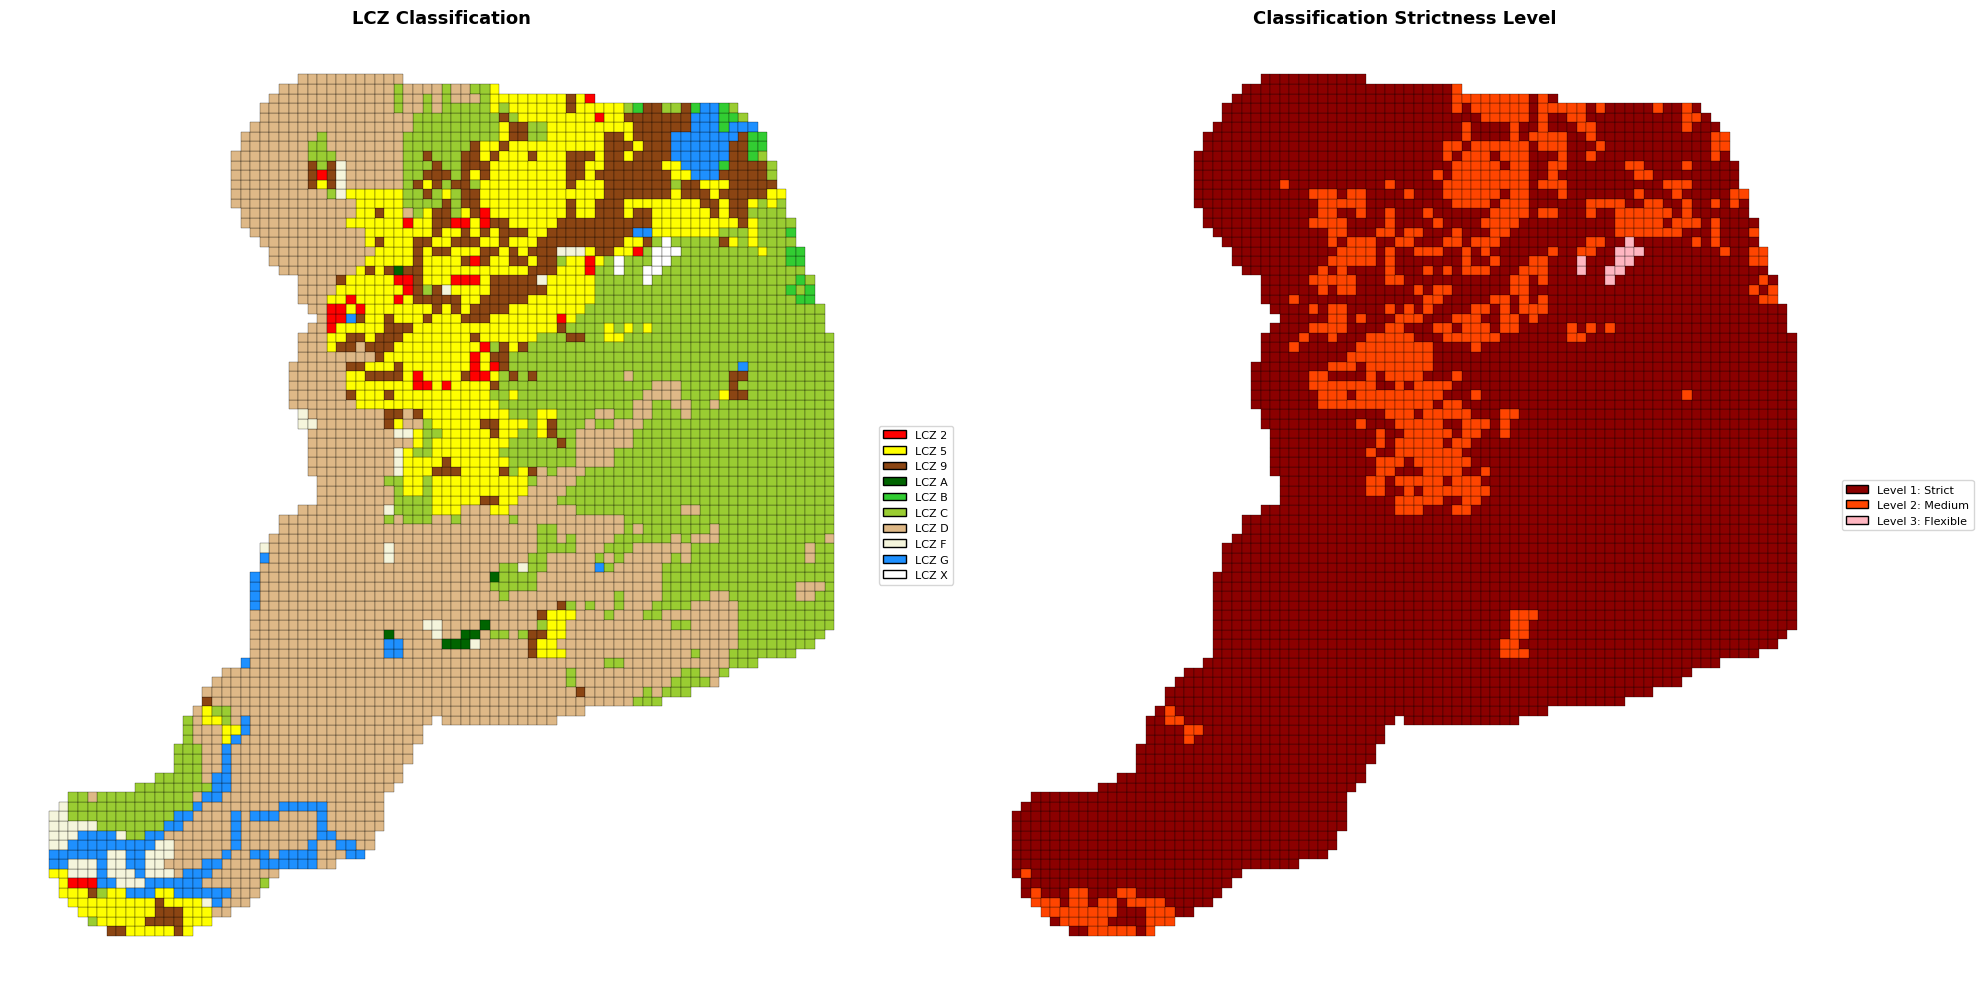

Saved -> 02_LCZ_Classification/lcz_and_strictness.png


In [65]:
LCZ_OUTPUT_DIR = r"02_LCZ_Classification"
os.makedirs(LCZ_OUTPUT_DIR, exist_ok=True)
LCZ_GPKG = os.path.join(LCZ_OUTPUT_DIR, "LCZ_Classification.gpkg")

classification_results = combined_gdf.apply(classify_lcz_waterfall, axis=1)
combined_gdf[['LCZ_final', 'Strictness_Level']] = pd.DataFrame(
    classification_results.tolist(), index=combined_gdf.index
)

print("LCZ distribution:")
print(combined_gdf['LCZ_final'].value_counts())
print("\nStrictness level distribution:")
print(combined_gdf['Strictness_Level'].value_counts().sort_index())

# ================== Merge LCZ results onto Variable_and_Phase_Statistics ==================
BASE_GPKG = r"../03_Variable_Zonal_Stats/Grid_Zonal_Stats/Grid_Zonal_Stats/02_Variable_and_Phase_Statistics.gpkg"

base_gdf = gpd.read_file(BASE_GPKG)
print(f"\nLoaded base gpkg: {len(base_gdf)} rows, columns: {list(base_gdf.columns)}")

base_gdf["GRID_ID"] = base_gdf["GRID_ID"].astype(str)
combined_gdf["GRID_ID"] = combined_gdf["GRID_ID"].astype(str)

# only bring over columns not already in base_gdf, plus the join key
lcz_cols = ["GRID_ID", "LC_Majority", "LCZ_final", "Strictness_Level"]
lcz_cols = [c for c in lcz_cols if c == "GRID_ID" or c not in base_gdf.columns]

lcz_only = combined_gdf[lcz_cols]

final_gdf = base_gdf.merge(lcz_only, on="GRID_ID", how="left")
final_gdf = gpd.GeoDataFrame(final_gdf, geometry="geometry", crs=base_gdf.crs)

n_missing_lcz = final_gdf["LCZ_final"].isna().sum()
if n_missing_lcz > 0:
    print(f"Warning: {n_missing_lcz} grid cell(s) in the base gpkg have no matching LCZ classification.")

final_gdf.to_file(LCZ_GPKG, driver="GPKG")
print(f"\nSaved -> {LCZ_GPKG}")
print(final_gdf.columns)


def plot_lcz_and_strictness(gdf, out_dir):
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))

    # LCZ map
    for lcz_type in gdf['LCZ_final'].dropna().unique():
        subset = gdf[gdf['LCZ_final'] == lcz_type]
        color = lcz_colors.get(lcz_type, '#FFFFFF')
        subset.plot(ax=axes[0], color=color, edgecolor='black', linewidth=0.2)
    axes[0].set_title('LCZ Classification', fontsize=13, fontweight='bold')
    axes[0].axis('off')

    lcz_order = ['LCZ 1','LCZ 2','LCZ 3','LCZ 4','LCZ 5','LCZ 6','LCZ 7','LCZ 8','LCZ 9','LCZ 10',
                 'LCZ A','LCZ B','LCZ C','LCZ D','LCZ E','LCZ F','LCZ G','LCZ X']
    present = [l for l in lcz_order if l in gdf['LCZ_final'].dropna().unique()]
    lcz_legend = [Patch(facecolor=lcz_colors[l], edgecolor='black', label=l) for l in present]
    axes[0].legend(handles=lcz_legend, loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8)

    # Strictness map
    for level in gdf['Strictness_Level'].dropna().unique():
        subset = gdf[gdf['Strictness_Level'] == level]
        color = strictness_colors.get(level, '#FFFFFF')
        subset.plot(ax=axes[1], color=color, edgecolor='black', linewidth=0.2)
    axes[1].set_title('Classification Strictness Level', fontsize=13, fontweight='bold')
    axes[1].axis('off')

    strictness_labels = {1: "Strict", 2: "Medium", 3: "Flexible", 0: "Unclassified"}
    present_levels = sorted(gdf['Strictness_Level'].dropna().unique())
    strict_legend = [Patch(facecolor=strictness_colors.get(lvl, '#FFFFFF'), edgecolor='black',
                             label=f"Level {lvl}: {strictness_labels.get(lvl, 'Unknown')}")
                      for lvl in present_levels]
    axes[1].legend(handles=strict_legend, loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8)

    plt.tight_layout()
    out_path = os.path.join(out_dir, "lcz_and_strictness.png")
    fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    return out_path


png_path = plot_lcz_and_strictness(final_gdf, LCZ_OUTPUT_DIR)
print(f"Saved -> {png_path}")